In [1]:
import os
import asp_plot

In [2]:
outdir = "~/Dropbox/UW_Shean/WV/2022/WV02_20220413_10300100D04DB500_10300100D0668800/"

ba_prefix = 'ba/ba_100ips_dg'

# topdir = '/nobackup/bpurint1/data/utqiagvik/WV/utqiagvik_wv_EE/2022'
# ba_prefix = 'csm_refinement_all_pairs/csm_out'

map_crs = 'EPSG:32604'
refdem = 'COP30_lzw-adj_proj.tif' # NOT needed, because geodiff output is: *-initial_residuals_pointmap-diff.csv, but useful for titling map
refdem_abbrv = refdem[0:5]

# Use to compare multi-stage bundle_adjust results
# compares the initial bundle_adjust output with post-pc_align bundle_adjust output
# should actually ALWAYS run this after the first step (if `pc_align` version exists)
two_stage = False

In [3]:
source = asp_plot.bundle_adjust_plots.ctx.providers.Esri.WorldImagery
#source = ctx.providers.Stamen.Terrain

ctx_kwargs = {'crs':map_crs, 'source':source, 'attribution_size':0, 'alpha':0.5}

In [4]:
resid_init_csv = os.path.join(outdir, ba_prefix + "-initial_residuals_pointmap.csv")
resid_final_csv = os.path.join(outdir, ba_prefix + "-final_residuals_pointmap.csv")

#This compares the initial bundle_adjust output with post-pc_align bundle_adjust output
if two_stage:
    resid_init_csv = ba_prefix + "-final_residuals_pointmap.csv"
    resid_final_csv = ba_prefix + "_pc_align-final_residuals_pointmap.csv"

In [5]:
resid_init = asp_plot.bundle_adjust_plots.read_residuals(resid_init_csv)
resid_final = asp_plot.bundle_adjust_plots.read_residuals(resid_final_csv)

In [6]:
resid_init.describe()



,lon,lat,height_above_datum,mean_residual,num_observations
count,1852.000000,1852.000000,1852.000000,1852.000000,1852.0
mean,-156.705441,71.335840,-166.201627,36.610264,2.0
std,0.144300,0.038537,3396.738347,104.078992,0.0
min,-157.062982,71.261371,-27288.167974,0.002405,2.0
25%,-156.824618,71.301724,2.708612,0.364863,2.0
50%,-156.738213,71.337689,8.431007,0.817892,2.0
75%,-156.616172,71.371065,12.517130,1.034607,2.0
max,-156.251792,71.403612,28770.329269,623.791160,2.0


In [7]:
resid_final.describe()

,lon,lat,height_above_datum,mean_residual,num_observations
count,1573.000000,1573.000000,1573.000000,1573.000000,1573.0
mean,-156.722102,71.337169,8.251879,0.293306,2.0
std,0.129732,0.038766,5.769562,0.238019,0.0
min,-156.893378,71.263947,0.155990,0.000046,2.0
25%,-156.829299,71.302019,3.031651,0.112057,2.0
50%,-156.749696,71.339618,8.488158,0.229862,2.0
75%,-156.647388,71.372766,11.521287,0.419122,2.0
max,-156.347956,71.399441,40.951157,1.507283,2.0


4.641129059261099e-05 425.7136454110111


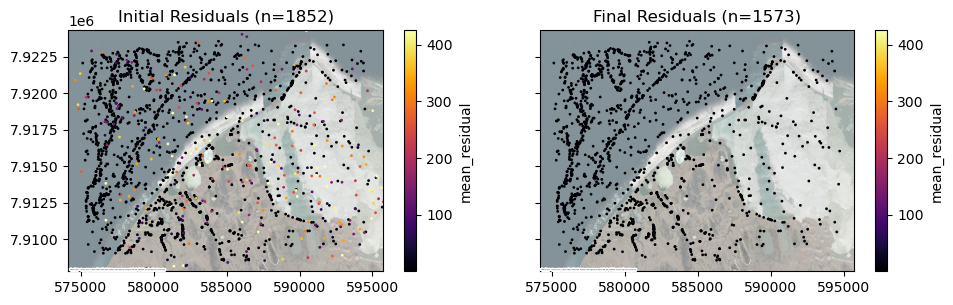

In [8]:
asp_plot.bundle_adjust_plots.resid_plot(resid_init, 
                                        resid_final, 
                                        col='mean_residual', 
                                        lognorm=False, 
                                        map_crs=map_crs,
                                        **ctx_kwargs)

4.641129059261099e-05 425.7136454110111


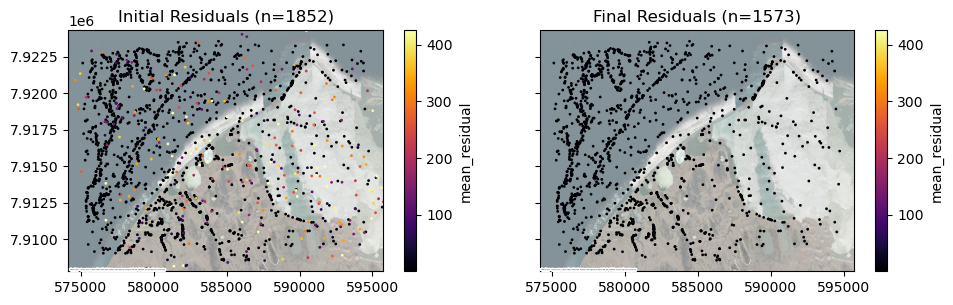

In [9]:
asp_plot.bundle_adjust_plots.resid_plot(resid_init, 
                                        resid_final, 
                                        col='mean_residual', 
                                        lognorm=False, 
                                        map_crs=map_crs,
                                        **ctx_kwargs)

2.0 2.0


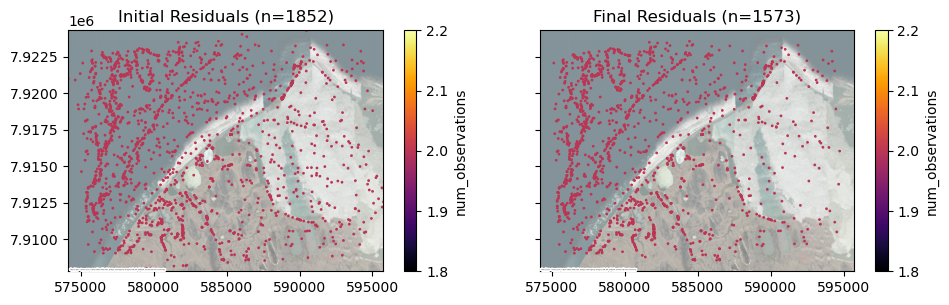

In [11]:
asp_plot.bundle_adjust_plots.resid_plot(resid_init, 
                                        resid_final, 
                                        col='num_observations', 
                                        map_crs=map_crs,
                                        **ctx_kwargs)